In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Uploading and Preparing data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oktayrdeki/heart-disease")

print("Path to dataset files:", 'heart_disease.csv')

100%|██████████| 568k/568k [00:00<00:00, 756kB/s]

Extracting files...
Path to dataset files: heart_disease.csv


In [ ]:
file_path = path + '/heart_disease.csv'
data = pd.read_csv(file_path)
data

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

# Data cleaning

In [ ]:
data.isna().sum()

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


In [ ]:
data['Alcohol Consumption']= data['Alcohol Consumption'].fillna('None')

In [ ]:
data['Alcohol Consumption'].value_counts()

,count
Alcohol Consumption,
None,2586
Medium,2500
Low,2488
High,2426


In [ ]:
data.isna().sum()

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


In [ ]:
data.dropna(inplace=True)

In [ ]:
data

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
5,25.0,Male,152.0,257.0,Low,Yes,No,No,28.144681,No,...,No,Low,Medium,5.504876,Low,126.0,91.0,4.297575,10.815983,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,None,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,None,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [ ]:
data.isna().sum()

,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Exercise Habits,0
Smoking,0
Family Heart Disease,0
Diabetes,0
BMI,0
High Blood Pressure,0


# EDA


In [ ]:
for i in data.select_dtypes(include='O'):
    print(data[i].value_counts(normalize=True)*100)
    print()

Gender
Female    50.020982
Male      49.979018
Name: proportion, dtype: float64

Exercise Habits
High      33.875367
Medium    33.329836
Low       32.794796
Name: proportion, dtype: float64

Smoking
Yes    51.258917
No     48.741083
Name: proportion, dtype: float64

Family Heart Disease
No     50.20982
Yes    49.79018
Name: proportion, dtype: float64

Diabetes
No     50.451112
Yes    49.548888
Name: proportion, dtype: float64

High Blood Pressure
Yes    50.094419
No     49.905581
Name: proportion, dtype: float64

Low HDL Cholesterol
Yes    50.241292
No     49.758708
Name: proportion, dtype: float64

High LDL Cholesterol
No     50.650441
Yes    49.349559
Name: proportion, dtype: float64

Alcohol Consumption
None      25.860260
Medium    25.083928
Low       24.874108
High      24.181704
Name: proportion, dtype: float64

Stress Level
Medium    33.885858
Low       33.308854
High      32.805287
Name: proportion, dtype: float64

Sugar Consumption
Low       34.032732
High      33.308854
Mediu

In [ ]:
data.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9532.000000,9532.000000,9532.000000,9532.000000,9532.000000,9532.000000,9532.000000,9532.000000,9532.000000
mean,49.325850,149.793433,225.288397,29.057661,6.989240,250.388166,120.099350,7.462227,12.448643
std,18.205866,17.578752,43.624616,6.293722,1.752605,87.127237,23.604012,4.343354,4.318686
min,18.000000,120.000000,150.000000,18.007058,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.656482,5.449181,176.000000,99.000000,3.662392,8.723334
50%,49.000000,150.000000,225.000000,29.056969,7.000719,250.000000,120.000000,7.458804,12.398044
75%,65.000000,165.000000,263.000000,34.477519,8.532454,326.000000,141.000000,11.236785,16.129292
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [ ]:
data.describe(include='O')

,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sugar Consumption,Heart Disease Status
count,9532,9532,9532,9532,9532,9532,9532,9532,9532,9532,9532,9532
unique,2,3,2,2,2,2,2,2,4,3,3,2
top,Female,High,Yes,No,No,Yes,Yes,No,None,Medium,Low,No
freq,4768,3229,4886,4786,4809,4775,4789,4828,2465,3230,3244,7621


`Pie Plots`

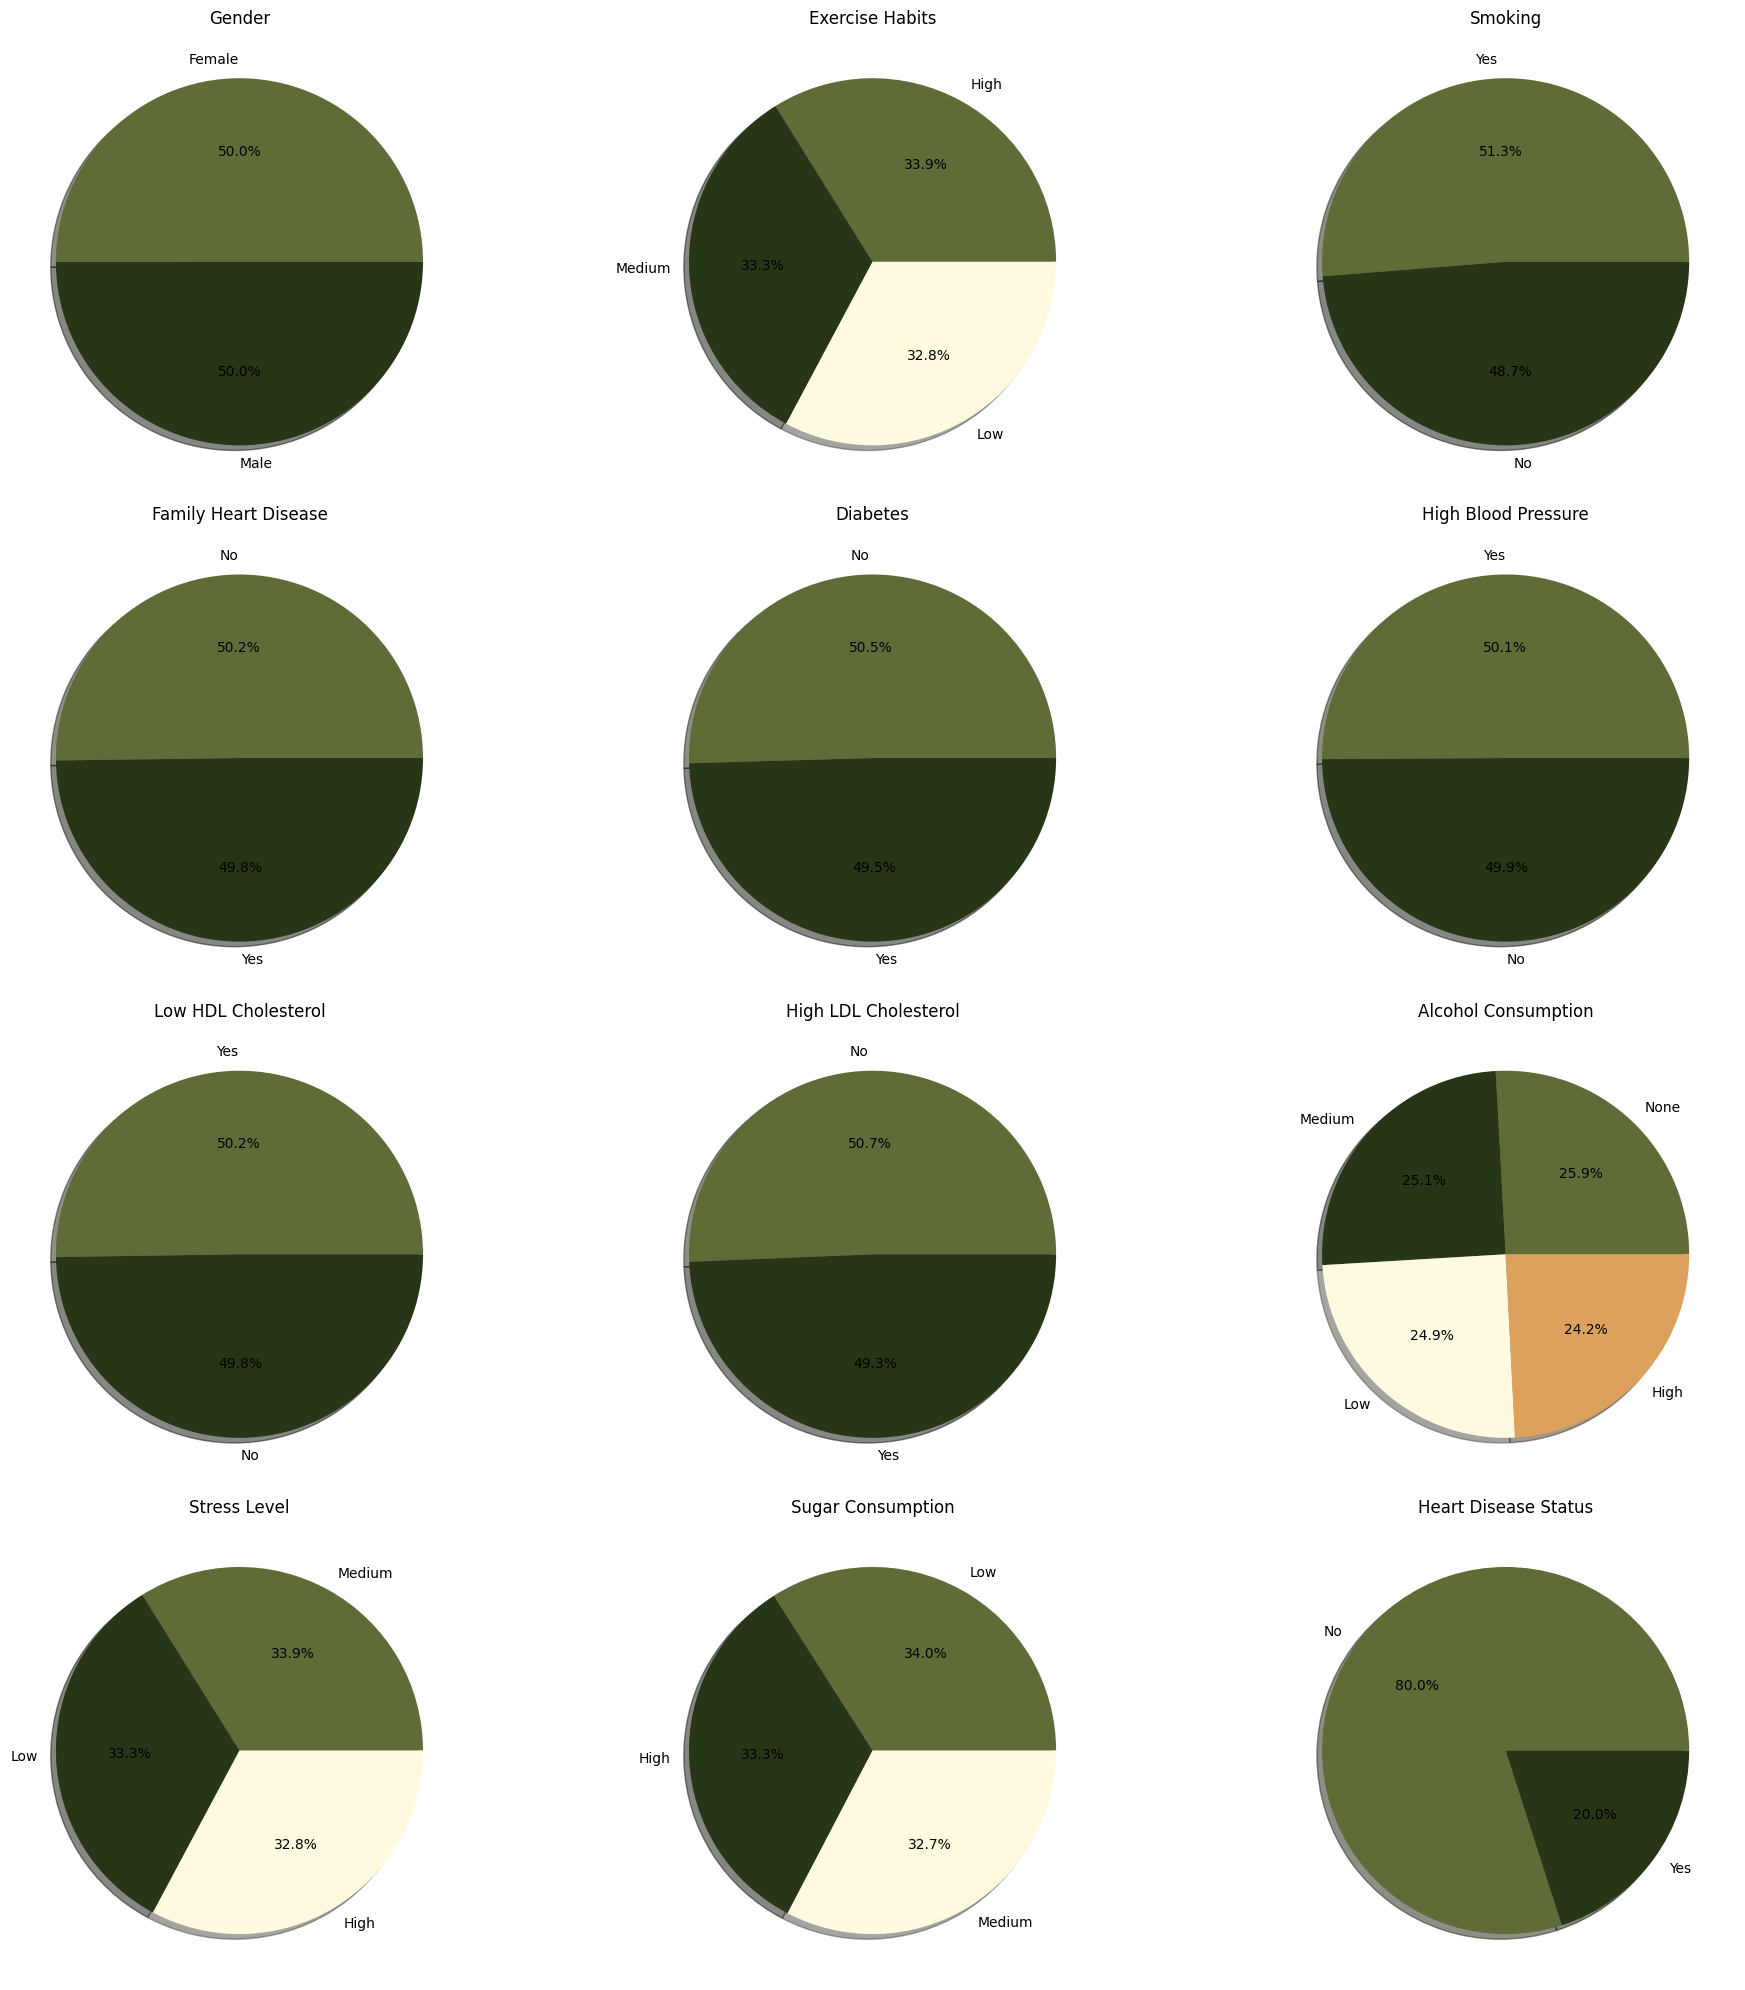

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()
colors=["#606C38","#283618","#FEFAE0",'#dda15e']

df_categorical = data[['Gender','Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes',
              'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']]

for i, var in enumerate(df_categorical.columns):
    counts = df_categorical[var].value_counts()
    axes[i].pie(counts.values,labels=counts.index,colors=colors,autopct='%1.1f%%',shadow=True)
    axes[i].set_title(var)

plt.tight_layout()
plt.show()

The categorical variables appear relatively balanced across their categories, as observed from the pie chart distributions. This suggests that the dataset does not suffer from severe class imbalance in most features.

`Histogram`

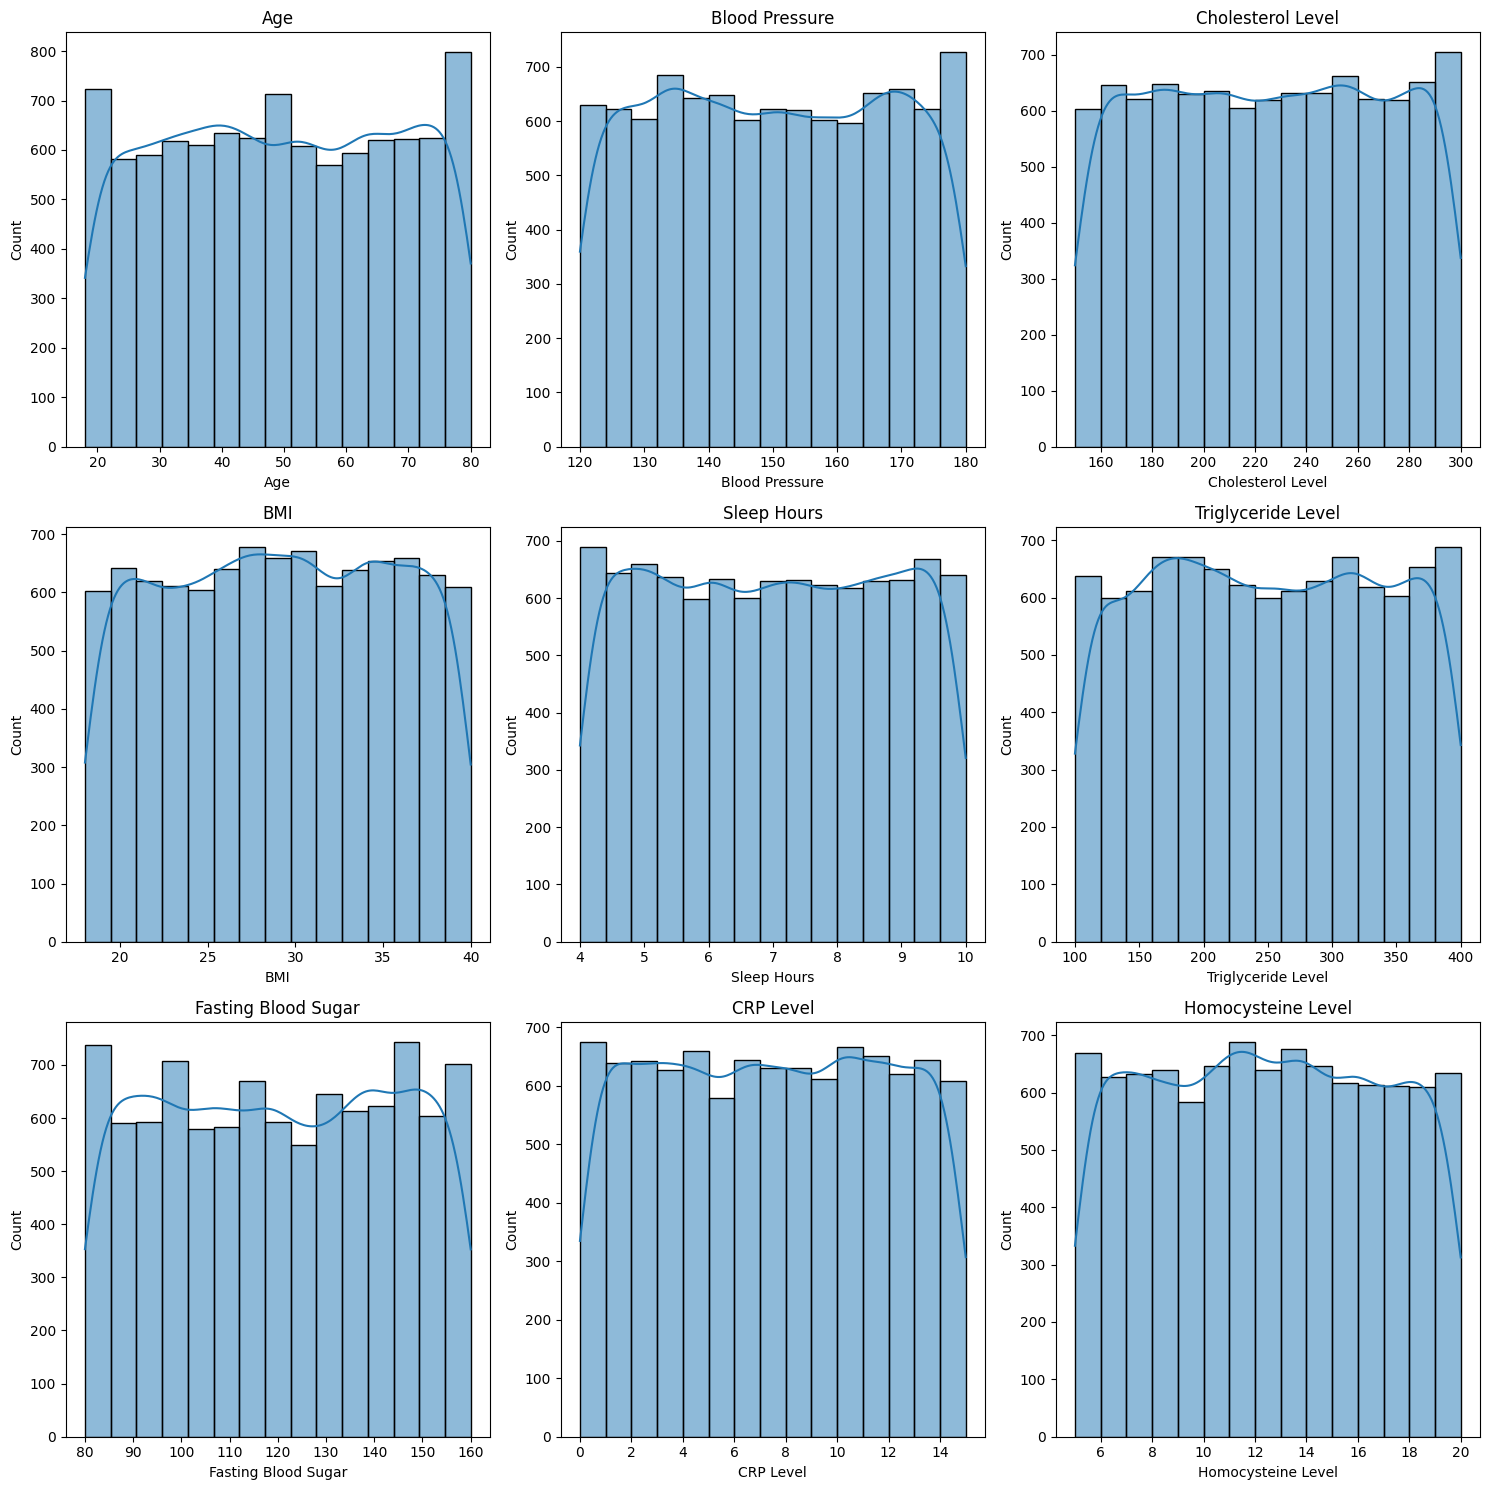

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15,15))
axes = axes.flatten()

df_numerical = data[['Age','Blood Pressure','Cholesterol Level','BMI','Sleep Hours','Triglyceride Level',
                     'Fasting Blood Sugar','CRP Level','Homocysteine Level']]

for i, var in enumerate(df_numerical.columns):
    sns.histplot(df_numerical[var],bins=15,kde=True,edgecolor='black',ax=axes[i])
    axes[i].set_title(var)

sns.set_style('darkgrid')
plt.tight_layout()
plt.show()

The distribution plots of numerical variables show relatively symmetric patterns with no extreme skewness, indicating that the mean is a reliable measure of central tendency for most features.

<Axes: >

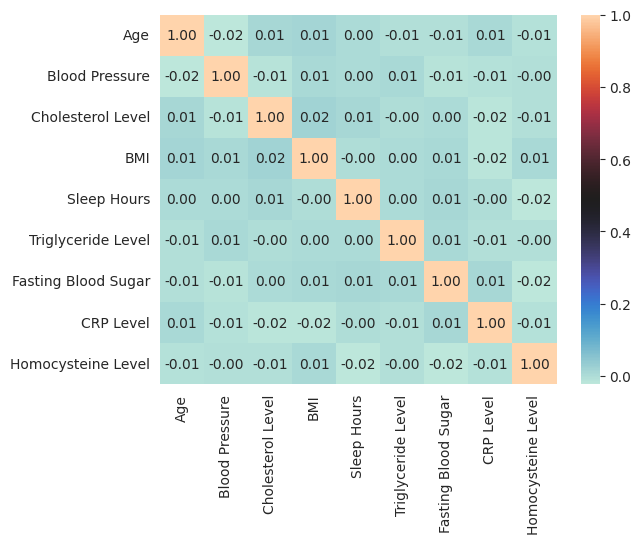

In [ ]:
corr=data.corr(numeric_only=True)
sns.heatmap(corr,annot=True,fmt='.2f',cmap='icefire')

# Demographic analysis

`Age`

In [ ]:
data.groupby(['Heart Disease Status','Gender'])['Age'].mean()

Heart Disease Status  Gender
No                    Female    49.523419
                      Male      49.233732
Yes                   Female    49.139535
                      Male      49.099783
Name: Age, dtype: float64

The average age of individuals with and without heart disease is nearly identical, suggesting that age alone may not be a strong differentiating factor within this dataset.

`Gender`

Heart disease status by age:
Heart Disease Status  Gender
No                    Male      3842
                      Female    3779
Yes                   Female     989
                      Male       922
Name: count, dtype: int64



Text(0.5, 1.0, 'Gender')

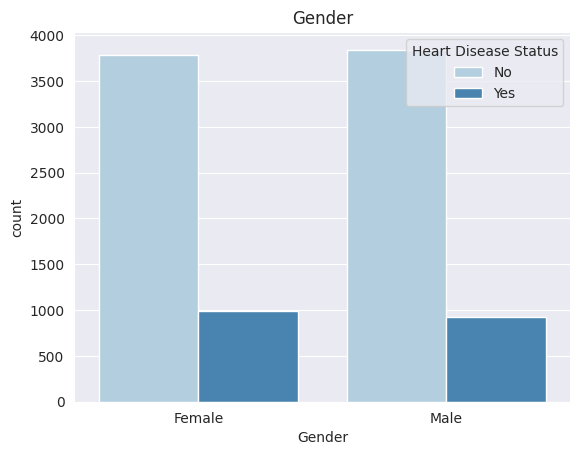

In [ ]:
gen_heart = data.groupby('Heart Disease Status')['Gender'].value_counts()
print(f'Heart disease status by age:\n{gen_heart}')
print()
# Visualization
sns.countplot(data=data,x='Gender',hue='Heart Disease Status',palette='Blues')
plt.title('Gender')

Females show a slightly higher proportion of heart disease cases compared to males; however, the difference is minimal and may not be statistically significant.

# Lifestyle analysis

`Exercise Habits`

Heart disease status by execrcise habits:
Heart Disease Status  Exercise Habits
No                    High               2584
                      Medium             2529
                      Low                2508
Yes                   Medium              648
                      High                645
                      Low                 618
Name: count, dtype: int64



Text(0.5, 1.0, 'Exercise Habits')

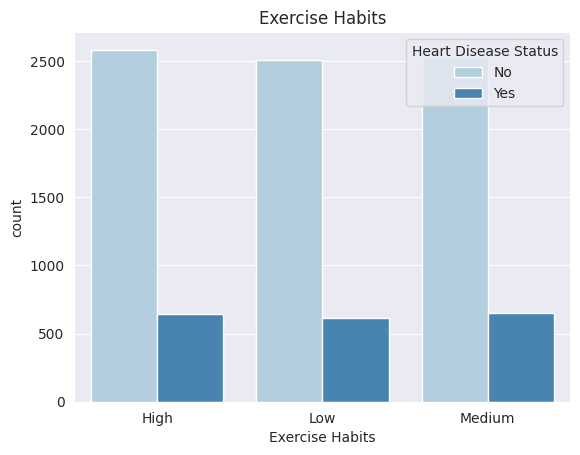

In [ ]:
ex_heart = data.groupby('Heart Disease Status')['Exercise Habits'].value_counts()
print(f'Heart disease status by execrcise habits:\n{ex_heart}')
print()
# Visualization
sns.countplot(data=data,x='Exercise Habits',hue='Heart Disease Status',palette='Blues')
plt.title('Exercise Habits')

`Smoking`

Heart disease status by smoking:
Heart Disease Status  Smoking
No                    Yes        3899
                      No         3722
Yes                   Yes         987
                      No          924
Name: count, dtype: int64



Text(0.5, 1.0, 'Smoking')

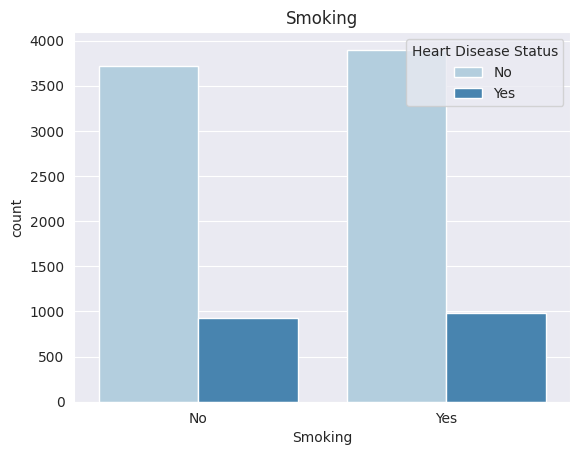

In [ ]:
sm_heart = data.groupby('Heart Disease Status')['Smoking'].value_counts()
print(f'Heart disease status by smoking:\n{sm_heart}')
print()
# Visualization
sns.countplot(data=data,x='Smoking',hue='Heart Disease Status',palette='Blues')
plt.title('Smoking')

`Alcohol Consumption`

Heart disease status by Alcohol Consumption:
Heart Disease Status  Alcohol Consumption
No                    None                   1989
                      Medium                 1919
                      Low                    1891
                      High                   1822
Yes                   High                    483
                      Low                     480
                      None                    476
                      Medium                  472
Name: count, dtype: int64



Text(0.5, 1.0, 'Alcohol Consumption')

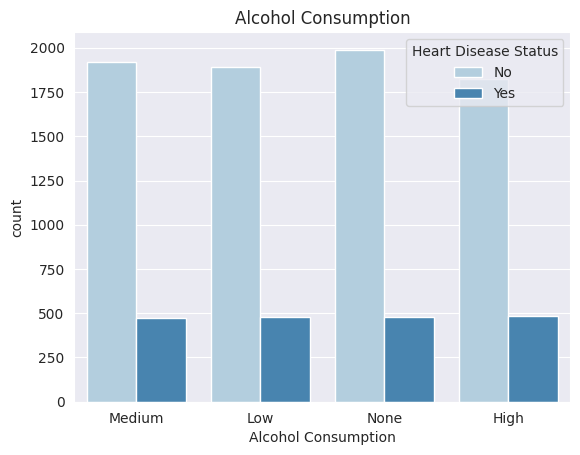

In [ ]:
al_heart = data.groupby('Heart Disease Status')['Alcohol Consumption'].value_counts()
print(f'Heart disease status by Alcohol Consumption:\n{al_heart}')
print()
# Visualization
sns.countplot(data=data,x='Alcohol Consumption',hue='Heart Disease Status',palette='Blues')
plt.title('Alcohol Consumption')

`Stress level`

Heart disease status by Stress Level:
Heart Disease Status  Stress Level
No                    Low             2586
                      Medium          2533
                      High            2502
Yes                   Medium           697
                      High             625
                      Low              589
Name: count, dtype: int64



Text(0.5, 1.0, 'Stress Level')

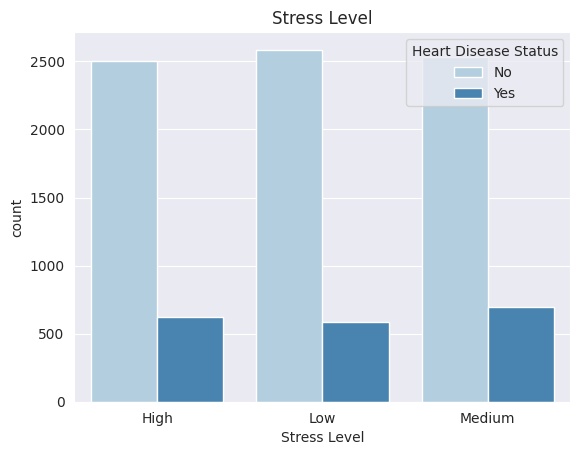

In [ ]:
st_heart = data.groupby('Heart Disease Status')['Stress Level'].value_counts()
print(f'Heart disease status by Stress Level:\n{st_heart}')
print()
# Visualization
sns.countplot(data=data,x='Stress Level',hue='Heart Disease Status',palette='Blues')
plt.title('Stress Level')

`Sugar consumption`

Heart disease status by Sugar Consumption:
Heart Disease Status  Sugar Consumption
No                    Low                  2607
                      High                 2511
                      Medium               2503
Yes                   High                  664
                      Low                   637
                      Medium                610
Name: count, dtype: int64



Text(0.5, 1.0, 'Sugar Consumption')

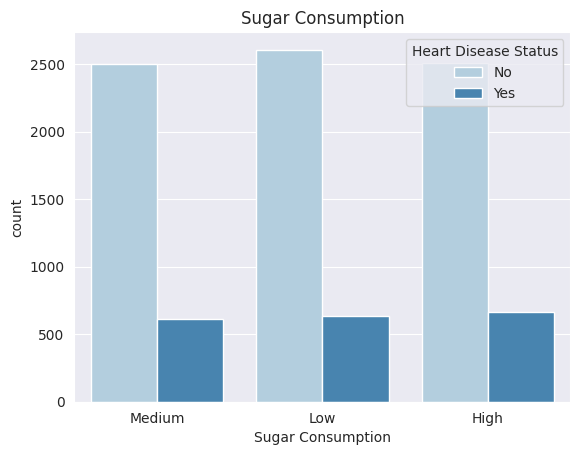

In [ ]:
su_heart = data.groupby('Heart Disease Status')['Sugar Consumption'].value_counts()
print(f'Heart disease status by Sugar Consumption:\n{su_heart}')
print()
# Visualization
sns.countplot(data=data,x='Sugar Consumption',hue='Heart Disease Status',palette='Blues')
plt.title('Sugar Consumption')

`Sleep hours`

In [ ]:
data.groupby('Heart Disease Status')['Sleep Hours'].mean()


,Sleep Hours
Heart Disease Status,
No,6.988975
Yes,6.990297





*   Smoking shows a slightly higher association with heart disease, indicating a potential but not dominant risk factor in this dataset.


*   Lifestyle-related variables such as alcohol consumption, sugar intake, stress level, and sleep duration do not exhibit strong visible patterns with heart disease when analyzed through basic distribution and count-based methods.


*   However, this does not necessarily imply the absence of relationships, but rather suggests that these effects may be subtle, non-linear, or require deeper statistical analysis to uncover.


# Medical analysis

`Cholesterol level`

In [ ]:
data.groupby('Heart Disease Status')['Cholesterol Level'].mean()

,Cholesterol Level
Heart Disease Status,
No,225.298911
Yes,225.246468


`High LDL Cholesterol`

Heart disease status by High LDL Cholesterol:
Heart Disease Status  High LDL Cholesterol
No                    No                      3878
                      Yes                     3743
Yes                   Yes                      961
                      No                       950
Name: count, dtype: int64



Text(0.5, 1.0, 'High LDL Cholesterol')

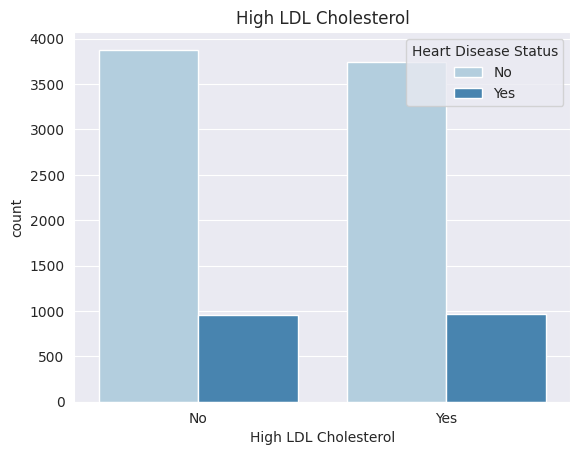

In [ ]:
hc_heart = data.groupby('Heart Disease Status')['High LDL Cholesterol'].value_counts()
print(f'Heart disease status by High LDL Cholesterol:\n{hc_heart}')
print()
# Visualization
sns.countplot(data=data,x='High LDL Cholesterol',hue='Heart Disease Status',palette='Blues')
plt.title('High LDL Cholesterol')

`Low LDL Cholesterol`

Heart disease status by Low HDL Cholesterol:
Heart Disease Status  Low HDL Cholesterol
No                    Yes                    3837
                      No                     3784
Yes                   No                      959
                      Yes                     952
Name: count, dtype: int64



Text(0.5, 1.0, 'Low HDL Cholesterol')

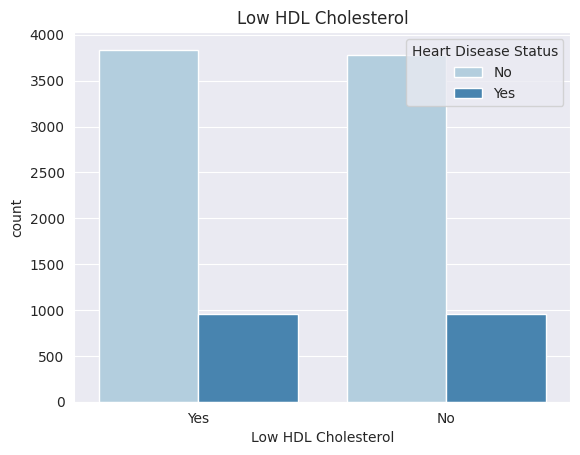

In [ ]:
lc_heart = data.groupby('Heart Disease Status')['Low HDL Cholesterol'].value_counts()
print(f'Heart disease status by Low HDL Cholesterol:\n{lc_heart}')
print()
# Visualization
sns.countplot(data=data,x='Low HDL Cholesterol',hue='Heart Disease Status',palette='Blues')
plt.title('Low HDL Cholesterol')

`Blood pressure`

In [ ]:
data.groupby('Heart Disease Status')['Blood Pressure'].mean()

,Blood Pressure
Heart Disease Status,
No,149.922320
Yes,149.279435


`High blood pressure`

Heart disease status by High Blood Pressure:
Heart Disease Status  High Blood Pressure
No                    Yes                    3817
                      No                     3804
Yes                   Yes                     958
                      No                      953
Name: count, dtype: int64



Text(0.5, 1.0, 'High Blood Pressure')

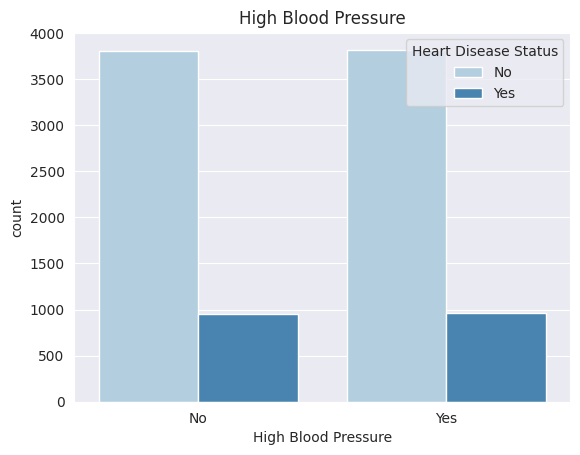

In [ ]:
hb_heart = data.groupby('Heart Disease Status')['High Blood Pressure'].value_counts()
print(f'Heart disease status by High Blood Pressure:\n{hb_heart}')
print()
# Visualization
sns.countplot(data=data,x='High Blood Pressure',hue='Heart Disease Status',palette='Blues')
plt.title('High Blood Pressure')

`Fasting blood sugar`

In [ ]:
data.groupby('Heart Disease Status')['Fasting Blood Sugar'].mean()

,Fasting Blood Sugar
Heart Disease Status,
No,120.160478
Yes,119.855573


`Diabetes`

Heart disease status by Diabetes:
Heart Disease Status  Diabetes
No                    No          3836
                      Yes         3785
Yes                   No           973
                      Yes          938
Name: count, dtype: int64



Text(0.5, 1.0, 'Diabetes')

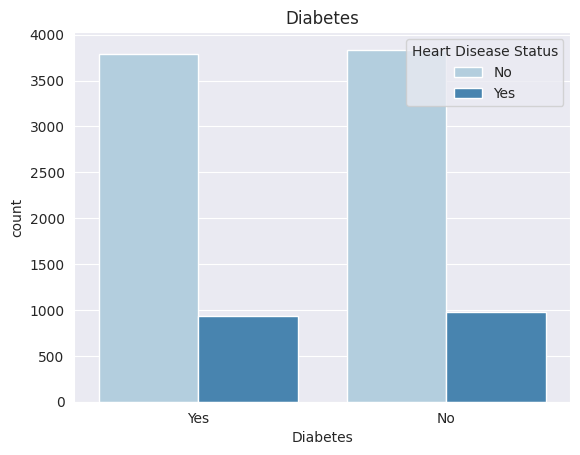

In [ ]:
d_heart = data.groupby('Heart Disease Status')['Diabetes'].value_counts()
print(f'Heart disease status by Diabetes:\n{d_heart}')
print()
# Visualization
sns.countplot(data=data,x='Diabetes',hue='Heart Disease Status',palette='Blues')
plt.title('Diabetes')

`BMI`

In [ ]:
data.groupby('Heart Disease Status')['BMI'].mean()

,BMI
Heart Disease Status,
No,28.991043
Yes,29.323335


`Triglyceride Level`

In [ ]:
data.groupby('Heart Disease Status')['Triglyceride Level'].mean()

,Triglyceride Level
Heart Disease Status,
No,250.287233
Yes,250.790686


`Family Heart Disease`

Heart disease status by Family Heart Disease:
Heart Disease Status  Family Heart Disease
No                    Yes                     3811
                      No                      3810
Yes                   No                       976
                      Yes                      935
Name: count, dtype: int64



Text(0.5, 1.0, 'Family Heart Disease')

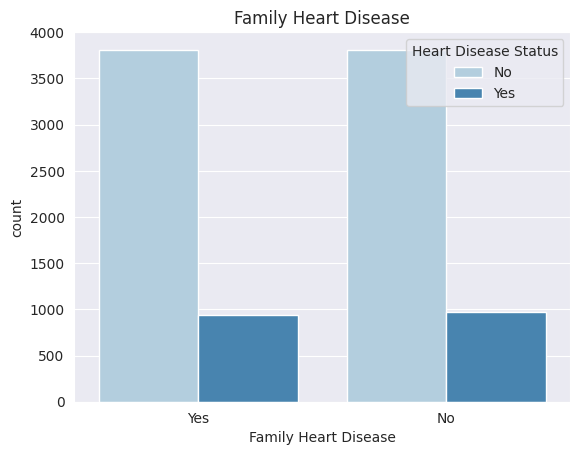

In [ ]:
fd_heart = data.groupby('Heart Disease Status')['Family Heart Disease'].value_counts()
print(f'Heart disease status by Family Heart Disease:\n{fd_heart}')
print()
# Visualization
sns.countplot(data=data,x='Family Heart Disease',hue='Heart Disease Status',palette='Blues')
plt.title('Family Heart Disease')

`CRP level`

In [ ]:
data.groupby('Heart Disease Status')['CRP Level'].mean()

,CRP Level
Heart Disease Status,
No,7.476157
Yes,7.406676




*   Medical indicators, including cholesterol levels, blood pressure, triglycerides, fasting blood sugar, CRP, and homocysteine levels, appear to have similar distributions across heart disease categories.



*   This suggests that no single medical variable strongly differentiates between patients with and without heart disease when considered independently.






# Insights



*   Overall, the analysis indicates that heart disease cannot be explained by a single factor alone. The weak patterns observed across demographic, lifestyle, and medical variables suggest that heart disease is likely influenced by a combination of multiple interacting factors rather than isolated variables.

*   Therefore, correlation analysis alone may not be sufficient to capture the true impact of features on heart disease risk.


